# Perch V2 — Zero-Shot vs Trained Classifier Evaluation

### Data format expected
- **WAV folder**: flat folder of `.wav` files named like `SCW1807_20200711_082500.wav`
- **Annotation JSON**: single JSON file mapping `SCW1807_20200711_082500-contours.json` → list of `{start, end, label}` dicts

### What this notebook does
1. Parses annotations → extracts **5s windows centered on each signal** (label = annotation label)
2. Extracts **fixed 5s background windows** from gap regions in each file (label = `background`)
3. Embeds all windows with **Perch V2**
4. Evaluates **zero-shot** performance using Perch V2's built-in logits
5. Trains a **linear classifier** on top of the embeddings
6. Reports **per-class precision / recall / F1** for both, with plots
6. Performs **Dimensinality Reduction** to asses class separation in 2D and cluster formation.


> **Requirements**: GPU runtime + perch-hoplite installed (cells below)

In order to use Perch V2, you must install this version (or later) of TensorFlow and cuda

In [ ]:
%pip install tensorflow[and-cuda]~=2.20.0rc0

Choose the working gpu

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [2]:
import tensorflow as tf
import torch

print(f"TF GPUs: {tf.config.list_physical_devices('GPU')}")
print(f"PyTorch: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    # Only use GPU 0
    tf.config.set_visible_devices(gpus[0], 'GPU')
    # Optional: prevent TF from grabbing all memory
    tf.config.experimental.set_memory_growth(gpus[0], True)
print(f"TF using: {tf.config.get_visible_devices('GPU')}")

2026-04-29 12:51:18.652507: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-29 12:51:18.706910: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-29 12:51:20.150630: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TF GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
PyTorch: NVIDIA L4
TF using: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
#@title Imports
import json
import warnings
from pathlib import Path
import os
import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay, classification_report,
    f1_score, precision_recall_fscore_support
)
import librosa.display
import soxr
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from perch_hoplite.zoo import model_configs

In [4]:
#@title Configuration { vertical-output: true }

#@markdown Folder containing all .wav files
wav_folder = '/data2/mromaniuc/cet-det/datasets/DOLPHINFREE/Single_hydrophone/inputs/Audio_data'  #@param {type:'string'}

#@markdown Folder for base saving
save_dir = '/data2/mromaniuc/cet-det/models/perch_v2/DOLPHINFREE'

#@markdown Path to your single annotation JSON file
annotation_json_path = '/data2/mromaniuc/cet-det/datasets/DOLPHINFREE/Single_hydrophone/inputs/fully_annotated_dataset.json'  #@param {type:'string'}

#@markdown Window size in seconds fed to Perch V2 (default 5.0)
window_size_s = 5.0  #@param {type:'number'}

#@markdown Minimum overlap (s) between an annotation and a window to label it as positive
min_overlap_s = 0.001  #@param {type:'number'}

#@markdown Fraction of data held out for testing
test_size = 0.3  #@param {type:'number'}

#@markdown Random seed
random_seed = 123  #@param {type:'number'}

In [5]:
#@title Load Perch V2 model
model_key = 'perch_v2'
embedding_model = model_configs.load_model_by_name(model_key)
sr = embedding_model.sample_rate

perch_class_names = list(embedding_model.class_list['labels'].classes)
print(f'Model loaded. Sample rate: {sr} Hz')
print(f'Perch V2 built-in classes: {len(perch_class_names)}')

I0000 00:00:1777459883.965104 3439418 gpu_device.cc:2020] Created device /device:GPU:0 with 1081 MB memory:  -> device: 0, name: NVIDIA L4, pci bus id: 0000:3b:00.0, compute capability: 8.9
I0000 00:00:1777459884.371431 3439418 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1081 MB memory:  -> device: 0, name: NVIDIA L4, pci bus id: 0000:3b:00.0, compute capability: 8.9


Model loaded. Sample rate: 32000 Hz
Perch V2 built-in classes: 14795


In [6]:
#@title Parse annotations and build window list

with open(annotation_json_path) as f:
    annot = json.load(f)

wav_folder = Path(wav_folder)
windows = []
missing_wavs = []

for json_key, annotations in annot.items():
    wav_stem = json_key.replace('-contours.json', '')
    wav_path = wav_folder / f'{wav_stem}.wav'

    if not wav_path.exists():
        missing_wavs.append(str(wav_path))
        continue

    duration = librosa.get_duration(path=str(wav_path))
    n_windows = int(duration // window_size_s)

    for i in range(n_windows):
        offset = i * window_size_s
        win_start = offset
        win_end = offset + window_size_s

        # Check overlap with any annotation
        label = 'background'
        for ann in annotations:
            overlap = min(win_end, ann['end']) - max(win_start, ann['start'])
            if overlap >= min_overlap_s:
                label = ann['label']
                break

        windows.append({'wav_path': str(wav_path), 'offset_s': offset, 'label': label})

windows_df = pd.DataFrame(windows)
print(f'Total windows: {len(windows_df)}')
if missing_wavs:
    print(f'WARNING: {len(missing_wavs)} WAV files not found (first 5: {missing_wavs[:5]})')
print('\nClass distribution:')
print(windows_df['label'].value_counts())

Total windows: 3290

Class distribution:
label
background    2140
whistle       1150
Name: count, dtype: int64


just to check wether we correctly assigned the labels:

In [8]:
#@title Visualize window labels per file

files = windows_df['wav_path'].unique()
n_files = min(275, len(files))  # plot up to 6 files
fig, axes = plt.subplots(n_files, 1, figsize=(15, 2.5 * n_files))
if n_files == 1:
    axes = [axes]

for ax, wav_path in zip(axes, files[:n_files]):
    file_windows = windows_df[windows_df['wav_path'] == wav_path].copy()
    duration = file_windows['offset_s'].max() + window_size_s

    # Draw windows as colored bars
    for _, row in file_windows.iterrows():
        color = 'steelblue' if row['label'] == 'whistle' else 'lightgray'
        ax.barh(0, window_size_s, left=row['offset_s'], height=0.5,
                color=color, edgecolor='white', linewidth=0.3)

    # Overlay raw annotation intervals
    wav_stem = Path(wav_path).stem
    json_key = f'{wav_stem}-contours.json'
    if json_key in annot:
        for ann in annot[json_key]:
            ax.barh(0.6, ann['end'] - ann['start'], left=ann['start'],
                    height=0.2, color='red', alpha=0.7)

    ax.set_xlim(0, duration)
    ax.set_yticks([0, 0.6])
    ax.set_yticklabels(['windows', 'annotations'])
    ax.set_xlabel('Time (s)')
    ax.set_title(Path(wav_path).name, fontsize=8)

plt.tight_layout()
plt.savefig(f'{save_dir}/figures/visualize_windows.png', dpi=100)
plt.close()  # prevents it from embedding in the notebook

In [6]:
import soxr
from tqdm import tqdm

embeddings_list, logits_list, labels_list, failed_idx = [], [], [], []
windows_df = windows_df.reset_index(drop=True)

for i, row in tqdm(windows_df.iterrows(), total=len(windows_df)):
    try:
        audio_native, native_sr = librosa.load(
            row['wav_path'], sr=None,
            offset=row['offset_s'], duration=window_size_s, mono=True
        )
        audio = soxr.resample(audio_native, native_sr, sr)
        target_len = int(window_size_s * sr)
        if len(audio) < target_len:
            audio = np.pad(audio, (0, target_len - len(audio)))
        audio = audio[:target_len].astype(np.float32)

        out = embedding_model.embed(audio)
        embeddings_list.append(out.embeddings[0].mean(axis=0))
        logits_list.append(out.logits['label'][0])
        labels_list.append(row['label'])
    except Exception as e:
        failed_idx.append(i)
        print(f'  FAILED [{i}] {Path(row["wav_path"]).name} @ {row["offset_s"]:.1f}s — {repr(e)}')
    if (i + 1) % 100 == 0:
        print(f'  {i+1}/{len(windows_df)} embedded...')

X = np.stack(embeddings_list)
Z = np.stack(logits_list)
y = np.array(labels_list)

print(f'\nDone. {len(X)} embedded, {len(failed_idx)} failed.')
print(f'Embedding shape: {X.shape}')

  0%|          | 0/3290 [00:00<?, ?it/s]2026-04-20 08:25:22.927829: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f56ac06dca0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-20 08:25:22.927867: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA L4, Compute Capability 8.9
2026-04-20 08:25:23.255553: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-20 08:25:23.302946: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 92100
2026-04-20 08:25:24.256275: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_55', 68 bytes spill stores, 68 bytes spill loads

2026-04-20 08:25:24.484065: I external/local_xla/xla/stream_executor/cuda/subprocess_co

  100/3290 embedded...


  6%|▌         | 204/3290 [00:22<02:30, 20.44it/s]

  200/3290 embedded...


  9%|▉         | 303/3290 [00:27<02:25, 20.48it/s]

...

  3100/3290 embedded...


 97%|█████████▋| 3204/3290 [02:45<00:04, 20.36it/s]

  3200/3290 embedded...


100%|██████████| 3290/3290 [02:49<00:00, 19.46it/s]


Done. 3290 embedded, 0 failed.
Embedding shape: (3290, 1536)


In [ ]:
#@title Save embeddings and metadata to Drive


os.makedirs(save_dir, exist_ok=True)

# --- Build raw arrays ---
succeeded_mask = [i for i in windows_df.index if i not in set(failed_idx)]
metadata_df = windows_df.loc[succeeded_mask].copy().reset_index(drop=True)
metadata_df['embedding_idx'] = metadata_df.index

# --- NaN diagnostic ---
nan_in_X = np.isnan(X).any(axis=1)
nan_in_Z = np.isnan(Z).any(axis=1)
nan_any = nan_in_X | nan_in_Z

print('=== NaN DIAGNOSTIC ===')
print(f'Total windows:          {len(X)}')
print(f'Rows with NaN in X:     {nan_in_X.sum()}')
print(f'Rows with NaN in Z:     {nan_in_Z.sum()}')
print(f'Rows with NaN in either:{nan_any.sum()}')

if nan_any.sum() > 0:
    print('\nAffected rows:')
    for idx in np.where(nan_any)[0]:
        label = y[idx]
        wav = Path(metadata_df.iloc[idx]['wav_path']).name
        offset = metadata_df.iloc[idx]['offset_s']
        nan_x = np.isnan(X[idx]).sum()
        nan_z = np.isnan(Z[idx]).sum()
        print(f'  row {idx:5d} | {label:10s} | {wav} @ {offset:.1f}s | NaN in X: {nan_x}, NaN in Z: {nan_z}')

    pct = nan_any.sum() / len(X) * 100
    if pct < 5.0:
        print(f'\n{nan_any.sum()} NaN rows ({pct:.2f}% of data) — safe to drop, proceeding.')
        valid = ~nan_any
        X_save = X[valid]
        Z_save = Z[valid]
        y_save = y[valid]
        metadata_save = metadata_df[valid].reset_index(drop=True)
        metadata_save['embedding_idx'] = metadata_save.index
    else:
        print(f'\nWARNING: {pct:.2f}% of data has NaN — too many to drop safely, investigate first.')
        print('Saving anyway with NaNs so you do not lose data — fix before training.')
        X_save, Z_save, y_save, metadata_save = X, Z, y, metadata_df
else:
    print('\nNo NaN values found — data is clean.')
    X_save, Z_save, y_save, metadata_save = X, Z, y, metadata_df

np.save(f'{save_dir}/embeddings/X_embeddings.npy', X_save)
np.save(f'{save_dir}/embeddings/Z_logits.npy', Z_save)
np.save(f'{save_dir}/embeddings/y_labels.npy', y_save)
metadata_save.to_csv(f'{save_dir}/embeddings/metadata.csv', index=False)

print(f'\n=== SAVED TO {save_dir} ===')
print(f'  X_embeddings.npy  — {X_save.shape}')
print(f'  Z_logits.npy      — {Z_save.shape}')
print(f'  y_labels.npy      — {y_save.shape}')
print(f'  metadata.csv      — {len(metadata_save)} rows')
print(f'\nClass distribution in saved data:')
print(pd.Series(y_save).value_counts())

=== NaN DIAGNOSTIC ===
Total windows:          3290
Rows with NaN in X:     0
Rows with NaN in Z:     0
Rows with NaN in either:0

No NaN values found — data is clean.

=== SAVED TO /data2/mromaniuc/cet-det/models/perch_v2/DOLPHINFREE ===
  X_embeddings.npy  — (3290, 1536)
  Z_logits.npy      — (3290, 14795)
  y_labels.npy      — (3290,)
  metadata.csv      — 3290 rows

Class distribution in saved data:
background    2140
whistle       1150
Name: count, dtype: int64


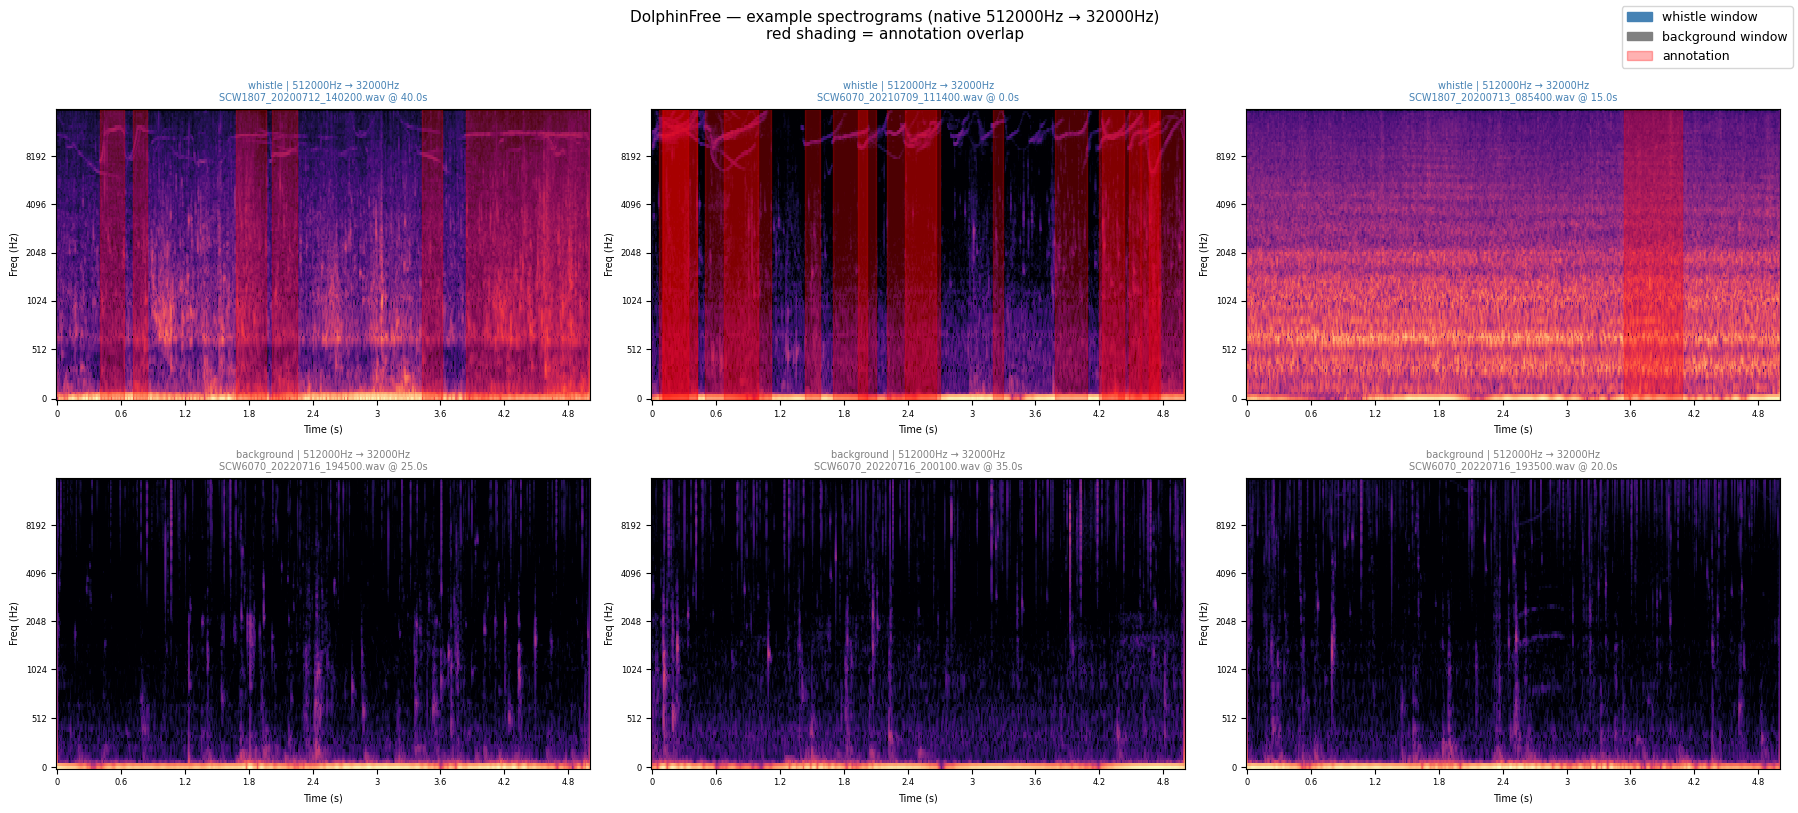

Saved → /data2/mromaniuc/cet-det/models/perch_v2/DOLPHINFREE/figures/example_spectrograms.png


In [14]:
#@title Visualize example spectrograms — DolphinFree
import librosa
import librosa.display
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import soxr
import numpy as np
from pathlib import Path
import os

fig, axes = plt.subplots(2, 3, figsize=(18, 8))

for row_idx, label in enumerate(['whistle', 'background']):
    subset  = windows_df[windows_df['label'] == label]
    samples = subset.sample(min(3, len(subset)), random_state=42).reset_index(drop=True)

    for col_idx, (_, row) in enumerate(samples.iterrows()):
        ax = axes[row_idx][col_idx]
        try:
            # ── load at native SR ─────────────────────────────────────────
            audio_native, native_sr = librosa.load(
                row['wav_path'], sr=None,
                offset=row['offset_s'], duration=window_size_s, mono=True
            )

            # ── resample to 32kHz for PERCHv2 ────────────────────────────
            audio = soxr.resample(audio_native, native_sr, sr)
            target_len = int(window_size_s * sr)
            if len(audio) < target_len:
                audio = np.pad(audio, (0, target_len - len(audio)))
            audio = audio[:target_len].astype(np.float32)

            # ── mel spectrogram — full 16kHz range ───────────────────────
            S    = librosa.feature.melspectrogram(
                y=audio, sr=sr,
                n_mels=128,
                fmin=0,
                fmax=sr // 2,
                hop_length=160,
                n_fft=1024
            )
            S_db = librosa.power_to_db(S, ref=np.max)

            librosa.display.specshow(
                S_db, sr=sr,
                x_axis='time', y_axis='mel',
                fmin=0, fmax=sr // 2,
                hop_length=160,
                ax=ax, cmap='magma'
            )

            # ── overlay annotation intervals ──────────────────────────────
            win_start = row['offset_s']
            win_end   = win_start + window_size_s

            wav_stem = Path(row['wav_path']).stem
            json_key = f'{wav_stem}-contours.json'
            if json_key in annot:
                for ann in annot[json_key]:
                    a_start = max(ann['start'], win_start) - win_start
                    a_end   = min(ann['end'],   win_end)   - win_start
                    if a_end > a_start:
                        ax.axvspan(a_start, a_end,
                                   color='red', alpha=0.3)

            title_color = 'steelblue' if label == 'whistle' else 'gray'
            ax.set_title(
                f'{label} | {native_sr}Hz → {sr}Hz\n'
                f'{Path(row["wav_path"]).name} @ {win_start:.1f}s',
                fontsize=7, color=title_color
            )
            ax.set_xlabel('Time (s)', fontsize=7)
            ax.set_ylabel('Freq (Hz)', fontsize=7)
            ax.tick_params(labelsize=6)

        except Exception as e:
            ax.set_title(f'ERROR\n{str(e)[:50]}', fontsize=7)
            ax.axis('off')

# ── legend ────────────────────────────────────────────────────────────────────
whistle_patch = mpatches.Patch(color='steelblue', label='whistle window')
bg_patch      = mpatches.Patch(color='gray',      label='background window')
ann_patch     = mpatches.Patch(color='red',       alpha=0.3, label='annotation')
fig.legend(handles=[whistle_patch, bg_patch, ann_patch],
           loc='upper right', fontsize=9)

plt.suptitle(
    f'DolphinFree — example spectrograms (native {native_sr}Hz → {sr}Hz)\n'
    f'red shading = annotation overlap',
    fontsize=11, y=1.01
)
plt.tight_layout()
os.makedirs(f'{save_dir}/figures', exist_ok=True)
plt.savefig(f'{save_dir}/figures/example_spectrograms.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {save_dir}/figures/example_spectrograms.png')

# retrieving the data and performing zero-shot and fully-supervised classifications

In [11]:
X_clean =  np.load(f'{save_dir}/embeddings/X_embeddings.npy')   # (9209, 1536)
y_clean = np.load(f'{save_dir}/embeddings/y_labels.npy')   # (9209,)
Z_clean = np.load(f'{save_dir}/embeddings/Z_logits.npy')   # (9209,)

metadata_clean = pd.read_csv(f'{save_dir}/embeddings/metadata.csv')

print(f'Clean shapes — X: {X_clean.shape}, Z: {Z_clean.shape}, y: {y_clean.shape}')
print(f'Class distribution:')
print(pd.Series(y_clean).value_counts())

Clean shapes — X: (3290, 1536), Z: (3290, 14795), y: (3290,)
Class distribution:
background    2140
whistle       1150
Name: count, dtype: int64


In [14]:
# Search for dolphin/whale/cetacean related classes
for name in perch_class_names:
    if any(term in name.lower() for term in ['dolphin', 'tursiops', 'whale', 'cetac', 'porpoise', 'whistle', 'cetacean', 'delphinus', 'delphin', 'cetacea']):
        print(name)

print("\n--- Water/noise/background ---")
for name in perch_class_names:
    if any(term in name.lower() for term in ['water', 'noise', 'background', 'ambient', 'silence', 'rain', 'wave', 'ocean', 'sea']):
        print(name)

Colibri delphinae
Delphinapterus leucas
Myzomela adolphinae
Phylloscopus whistleri
Tursiops truncatus

--- Water/noise/background ---
Anstisia rosea
Anthus roseatus
Ardenna grisea
Boat_and_Water_vehicle
Cinnyris osea
Conocephalus oceanicus
Coracina caeruleogrisea
Ducula oceanica
Formicivora grisea
Gull_and_seagull
Lycalopex grisea
Microwave_oven
Myiagra oceanica
Myopsalta waterhousei
Myrmotherula grisea
Ocean
Oceanites gracilis
Oceanites oceanicus
Oceanites pincoyae
Petroica rosea
Platycleis grisea
Poecilimon ukrainicus
Prioniturus waterstradti
Psittacula roseata
Rain
Raindrop
Rhodinocichla rosea
Rhodostethia rosea
Sarothrura watersi
Streptopelia roseogrisea
Tachycineta euchrysea
Tamasa rainbowi
Teleogryllus oceanicus
Thalurania watertonii
Traffic_noise_and_roadway_noise
Train
Water
Water_tap_and_faucet
Waves_and_surf
Zoothera talaseae


In [18]:
#@title Zero-shot species analysis — what does Perch think your sounds are?

# Get the class names in order
class_names_list = list(embedding_model.class_list['labels'].classes)

# Separate whistle and background logits
whistle_mask = y_clean == 'whistle'
background_mask = y_clean == 'background'

Z_whistle = Z_clean[whistle_mask]
Z_background = Z_clean[background_mask]

# Mean logit per class across all whistle windows
mean_logits_whistle = Z_whistle.mean(axis=0)
mean_logits_background = Z_background.mean(axis=0)

# Top 20 classes for whistles
top_whistle_idx = np.argsort(mean_logits_whistle)[::-1][:20]
print('TOP 20 PERCH CLASSES FOR WHISTLE WINDOWS:')
print('-' * 50)
for idx in top_whistle_idx:
    print(f'  {mean_logits_whistle[idx]:6.3f}  {class_names_list[idx]}')

print()

# Top 20 classes for background
top_background_idx = np.argsort(mean_logits_background)[::-1][:20]
print('TOP 20 PERCH CLASSES FOR BACKGROUND WINDOWS:')
print('-' * 50)
for idx in top_background_idx:
    print(f'  {mean_logits_background[idx]:6.3f}  {class_names_list[idx]}')

print()


# Classes to investigate
whistle_candidates = {
    'Tursiops truncatus': class_names_list.index('Tursiops truncatus'),
    'Delphinapterus leucas': class_names_list.index('Delphinapterus leucas'),
}

background_candidates = {
    'Water': class_names_list.index('Water'),
    'Ocean': class_names_list.index('Ocean'),
    'Boat_and_Water_vehicle': class_names_list.index('Boat_and_Water_vehicle'),
}

print('\nWHISTLE CANDIDATES — mean logit for whistle vs background windows:')
print('-' * 70)
for name, idx in whistle_candidates.items():
    w_logit = mean_logits_whistle[idx]
    b_logit = mean_logits_background[idx]
    w_rank = np.where(np.argsort(mean_logits_whistle)[::-1] == idx)[0][0] + 1
    b_rank = np.where(np.argsort(mean_logits_background)[::-1] == idx)[0][0] + 1
    print(f'  {name:30s}  whistle: {w_logit:6.3f} (#{w_rank:4d})   background: {b_logit:6.3f} (#{b_rank:4d})   gap: {w_logit - b_logit:+.3f}')

print('\nBACKGROUND CANDIDATES — mean logit for background vs whistle windows:')
print('-' * 70)
for name, idx in background_candidates.items():
    w_logit = mean_logits_whistle[idx]
    b_logit = mean_logits_background[idx]
    w_rank = np.where(np.argsort(mean_logits_background)[::-1] == idx)[0][0] + 1
    b_rank = np.where(np.argsort(mean_logits_whistle)[::-1] == idx)[0][0] + 1
    print(f'  {name:30s}  background: {b_logit:6.3f} (#{w_rank:4d})   whistle: {w_logit:6.3f} (#{b_rank:4d})   gap: {b_logit - w_logit:+.3f}')

TOP 20 PERCH CLASSES FOR WHISTLE WINDOWS:
--------------------------------------------------
   7.235  Water
   6.771  Domestic_sounds_and_home_sounds
   6.604  Liquid
   6.448  Animal
   5.894  Stream
   5.782  Calypte costae
   5.682  Vehicle
   5.342  Molothrus ater
   5.311  Rain
   5.135  Engine
   5.076  Wild_animals
   5.008  Strix varia
   5.003  Mechanisms
   4.899  Molothrus aeneus
   4.894  Sturnus vulgaris
   4.872  Motor_vehicle_(road)
   4.747  Turdus merula
   4.725  Sink_(filling_or_washing)
   4.679  Cardinalis cardinalis
   4.672  Toilet_flush

TOP 20 PERCH CLASSES FOR BACKGROUND WINDOWS:
--------------------------------------------------
   7.804  Water
   7.404  Liquid
   6.908  Domestic_sounds_and_home_sounds
   6.190  Animal
   6.069  Rain
   5.837  Stream
   5.384  Vehicle
   5.271  Sink_(filling_or_washing)
   5.182  Wind
   5.134  Mechanisms
   4.974  Wild_animals
   4.964  Crackle
   4.893  Gurgling
   4.881  Toilet_flush
   4.874  Splash_and_splatter
   4.804

In [15]:
#@title Train / test split
le = LabelEncoder()
y_enc = le.fit_transform(y_clean)
class_names = list(le.classes_)
print('Classes:', class_names)

X_train, X_test, y_train, y_test, Z_train, Z_test = train_test_split(
    X_clean, y_enc, Z_clean,
    test_size=test_size,
    random_state=random_seed,
    stratify=y_enc
)
print(f'Train: {len(X_train)}  |  Test: {len(X_test)}')

Classes: ['background', 'whistle']
Train: 2303  |  Test: 987


In [20]:
#@title Zero-shot evaluation (Perch V2 built-in logits)
#@markdown Perch V2 was trained on bird/mammal/etc. taxonomy — 'whistle' and 'background'
#@markdown are not in its class list, so zero-shot will likely score poorly unless you
#@markdown manually map your labels to the closest Perch species below.
#@markdown
#@markdown Example: label_to_perch = {'whistle': 'common_dolphin', 'background': None}
#@markdown Set a label to None to exclude it (scores -inf, always loses).

label_to_perch = {'whistle': 'Tursiops truncatus', 'background': 'Water'}

def auto_match(label, perch_names):
    """Substring match — edit label_to_perch manually for better results."""
    label_lower = label.lower()
    for name in perch_names:
        if label_lower in name.lower() or name.lower() in label_lower:
            return name
    return None

final_mapping = {}
for cls in class_names:
    final_mapping[cls] = label_to_perch.get(cls, auto_match(cls, perch_class_names))

print('Label → Perch V2 class mapping:')
for k, v in final_mapping.items():
    status = '✓' if v else '✗ NOT FOUND'
    print(f'  {k:30s} → {str(v):40s} {status}')

def zero_shot_predict(Z_subset):
    preds = []
    for logits in Z_subset:
        scores = {}
        for cls in class_names:
            pname = final_mapping.get(cls)
            scores[cls] = logits[perch_class_names.index(pname)] if pname and pname in perch_class_names else -np.inf
        preds.append(max(scores, key=scores.get))
    return le.transform(preds)

y_pred_zs = zero_shot_predict(Z_test)

print('\n' + '='*60)
print('ZERO-SHOT (Perch V2 built-in logits)')
print('='*60)
print(classification_report(y_test, y_pred_zs, target_names=class_names))

Label → Perch V2 class mapping:
  background                     → Water                                    ✓
  whistle                        → Tursiops truncatus                       ✓

ZERO-SHOT (Perch V2 built-in logits)
              precision    recall  f1-score   support

  background       0.65      1.00      0.79       642
     whistle       0.00      0.00      0.00       345

    accuracy                           0.65       987
   macro avg       0.33      0.50      0.39       987
weighted avg       0.42      0.65      0.51       987



/data2/mromaniuc/cet-det/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/data2/mromaniuc/cet-det/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/data2/mromaniuc/cet-det/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

In [16]:
#@title Train classifiers + track ROC-AUC & overfitting metrics
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, roc_curve, f1_score, classification_report
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import time

# Pre-scale once to avoid redundant scaling inside pipelines (speeds up XGBoost eval)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

classifiers = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=random_seed, class_weight='balanced'))
    ]),
    'Decision Tree': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', DecisionTreeClassifier(max_depth=10, random_state=random_seed, class_weight='balanced'))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(n_estimators=200, random_state=random_seed, class_weight='balanced', n_jobs=-1))
    ]),
    'SVM (RBF)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='rbf', class_weight='balanced', random_state=random_seed, probability=True))
    ]),
}

results = {}
roc_data = {}

for name, pipeline in classifiers.items():
    print(f'\nTraining {name}...')
    t0 = time.time()

    # Handle XGBoost separately to enable per-round evaluation
    if 'XGBoost' in name:
        xgb = pipeline.named_steps['clf']
        xgb.fit(X_train_sc, y_train,
                eval_set=[(X_train_sc, y_train), (X_test_sc, y_test)],
                eval_metric='logloss',
                verbose=False)
        y_pred = xgb.predict(X_test_sc)
        y_proba = xgb.predict_proba(X_test_sc)[:, 1]
        evals_result = xgb.evals_result()
        elapsed = time.time() - t0
    else:
        # Replace internal scaler with pre-scaled data to avoid double scaling
        pipe_copy = Pipeline([('clf', pipeline.named_steps['clf'])])
        pipe_copy.fit(X_train_sc, y_train)
        y_pred = pipe_copy.predict(X_test_sc)

        # Get probabilities or decision scores
        if hasattr(pipe_copy, 'predict_proba'):
            y_proba = pipe_copy.predict_proba(X_test_sc)[:, 1]
        else:
            y_proba = pipe_copy.decision_function(X_test_sc)

        elapsed = time.time() - t0

    # Metrics
    f1_macro = f1_score(y_test, y_pred, average='macro')
    f1_per_class = f1_score(y_test, y_pred, average=None, labels=range(len(class_names)))
    train_acc = pipe_copy.score(X_train_sc, y_train) if 'XGBoost' not in name else xgb.score(X_train_sc, y_train)
    test_acc = pipe_copy.score(X_test_sc, y_test) if 'XGBoost' not in name else xgb.score(X_test_sc, y_test)
    auc = roc_auc_score(y_test, y_proba)
    fpr, tpr, _ = roc_curve(y_test, y_proba)

    results[name] = {
        'y_pred': y_pred, 'y_proba': y_proba, 'pipeline': pipe_copy if 'XGBoost' not in name else xgb,
        'f1_macro': f1_macro, 'f1_per_class': f1_per_class,
        'train_acc': train_acc, 'test_acc': test_acc,
        'time_s': elapsed, 'evals_result': evals_result if 'XGBoost' in name else None
    }
    roc_data[name] = {'fpr': fpr, 'tpr': tpr, 'auc': auc}

    print(f'  Time: {elapsed:.1f}s | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f} | Macro F1: {f1_macro:.4f} | ROC AUC: {auc:.4f}')
    print(classification_report(y_test, y_pred, target_names=class_names))

# Summary table
print('\n' + '='*95)
print('SUMMARY — MACRO F1 + ROC AUC + OVERFITTING CHECK')
print('='*95)
print(f'{"Classifier":<20} {"Macro F1":>8} {"ROC AUC":>8} {"Train Acc":>10} {"Test Acc":>10} {"Gap":>6} {"Time(s)":>8}')
print('-'*95)
for name, res in sorted(results.items(), key=lambda x: x[1]['f1_macro'], reverse=True):
    gap = abs(res['train_acc'] - res['test_acc'])
    print(f'{name:<20} {res["f1_macro"]:>8.4f} {roc_data[name]["auc"]:>8.4f} {res["train_acc"]:>10.4f} {res["test_acc"]:>10.4f} {gap:>6.4f} {res["time_s"]:>8.1f}')


Training Logistic Regression...
  Time: 0.2s | Train Acc: 1.0000 | Test Acc: 0.8855 | Macro F1: 0.8755 | ROC AUC: 0.9496
              precision    recall  f1-score   support

  background       0.92      0.90      0.91       642
     whistle       0.82      0.86      0.84       345

    accuracy                           0.89       987
   macro avg       0.87      0.88      0.88       987
weighted avg       0.89      0.89      0.89       987


Training Decision Tree...
  Time: 3.7s | Train Acc: 0.9744 | Test Acc: 0.8582 | Macro F1: 0.8458 | ROC AUC: 0.7856
              precision    recall  f1-score   support

  background       0.90      0.88      0.89       642
     whistle       0.78      0.82      0.80       345

    accuracy                           0.86       987
   macro avg       0.84      0.85      0.85       987
weighted avg       0.86      0.86      0.86       987


Training Random Forest...
  Time: 1.2s | Train Acc: 1.0000 | Test Acc: 0.9098 | Macro F1: 0.9022 | ROC AUC:

  Time: 7.6s | Train Acc: 0.9457 | Test Acc: 0.9119 | Macro F1: 0.9062 | ROC AUC: 0.9648
              precision    recall  f1-score   support

  background       0.97      0.89      0.93       642
     whistle       0.82      0.95      0.88       345

    accuracy                           0.91       987
   macro avg       0.90      0.92      0.91       987
weighted avg       0.92      0.91      0.91       987


SUMMARY — MACRO F1 + ROC AUC + OVERFITTING CHECK
Classifier           Macro F1  ROC AUC  Train Acc   Test Acc    Gap  Time(s)
-----------------------------------------------------------------------------------------------
SVM (RBF)              0.9062   0.9648     0.9457     0.9119 0.0339      7.6
Random Forest          0.9022   0.9572     1.0000     0.9098 0.0902      1.2
Logistic Regression    0.8755   0.9496     1.0000     0.8855 0.1145      0.2
Decision Tree          0.8458   0.7856     0.9744     0.8582 0.1162      3.7


In [17]:
#@title PyTorch MLP with Dropout

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, roc_auc_score, roc_curve, accuracy_score
import numpy as np
import copy
import time

# ── Architecture definitions ──────────────────────────────────────────────────
torch_mlp_configs = {
    'PyTorch MLP (128) drop=0.4': {
        'hidden': (128,),
        'dropout': 0.4,
        'lr': 1e-4,
        'weight_decay': 1e-3,
        'epochs': 300,
        'patience': 30,
        'batch_size': 256,
    },
    'PyTorch MLP (64) drop=0.4': {
        'hidden': (64,),
        'dropout': 0.4,
        'lr': 1e-4,
        'weight_decay': 1e-3,
        'epochs': 300,
        'patience': 30,
        'batch_size': 256,
    },
}

# ── Model builder ─────────────────────────────────────────────────────────────
def build_mlp(input_dim, hidden_sizes, dropout):
    layers = []
    in_dim = input_dim
    for h in hidden_sizes:
        layers += [nn.Linear(in_dim, h), nn.ReLU(), nn.Dropout(dropout)]
        in_dim = h
    layers.append(nn.Linear(in_dim, 1))
    return nn.Sequential(*layers)

# ── Data prep ─────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

y_train_bin = (y_train == class_names.index('whistle')).astype(np.float32)
y_test_bin  = (y_test  == class_names.index('whistle')).astype(np.float32)

print(f'y_train_bin — bg: {(y_train_bin==0).sum()}  whistle: {(y_train_bin==1).sum()}')
print(f'y_test_bin  — bg: {(y_test_bin==0).sum()}   whistle: {(y_test_bin==1).sum()}')

# Class weights for loss — no SMOTE needed
n_bg      = (y_train_bin == 0).sum()
n_whistle = (y_train_bin == 1).sum()
pos_weight = torch.tensor([n_bg / n_whistle], dtype=torch.float32).to(device)
print(f'pos_weight: {pos_weight.item():.3f}')

# ── Training loop ─────────────────────────────────────────────────────────────
mlp_results  = {}
mlp_roc_data = {}

for name, cfg in torch_mlp_configs.items():
    print(f'\nTraining {name}...')

    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train_sc, y_train_bin, test_size=0.15,
        random_state=random_seed, stratify=y_train_bin
    )

    X_tr_t  = torch.tensor(X_tr,      dtype=torch.float32).to(device)
    y_tr_t  = torch.tensor(y_tr,      dtype=torch.float32).to(device)
    X_val_t = torch.tensor(X_val,     dtype=torch.float32).to(device)
    y_val_t = torch.tensor(y_val,     dtype=torch.float32).to(device)
    X_te_t  = torch.tensor(X_test_sc, dtype=torch.float32).to(device)

    loader = DataLoader(TensorDataset(X_tr_t, y_tr_t),
                        batch_size=cfg['batch_size'], shuffle=True)

    input_dim = X_train_sc.shape[1]
    model     = build_mlp(input_dim, cfg['hidden'], cfg['dropout']).to(device)
    optimizer = torch.optim.Adam(model.parameters(),
                                 lr=cfg['lr'], weight_decay=cfg['weight_decay'])
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    best_val_loss  = float('inf')
    patience_counter = 0
    best_state     = None
    train_losses, val_losses = [], []
    train_accs,   val_accs   = [], []
    best_epoch     = 0
    early_stopped  = False

    t0 = time.time()

    for epoch in range(1, cfg['epochs'] + 1):
        model.train()
        for xb, yb in loader:
            optimizer.zero_grad()
            criterion(model(xb).squeeze(1), yb).backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            tr_logits  = model(X_tr_t).squeeze(1)
            val_logits = model(X_val_t).squeeze(1)

            tr_loss  = criterion(tr_logits,  y_tr_t).item()
            val_loss = criterion(val_logits, y_val_t).item()
            tr_acc   = ((tr_logits  > 0) == y_tr_t.bool()).float().mean().item()
            val_acc  = ((val_logits > 0) == y_val_t.bool()).float().mean().item()

        train_losses.append(tr_loss)
        val_losses.append(val_loss)
        train_accs.append(tr_acc)
        val_accs.append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            patience_counter = 0
            best_epoch       = epoch
            best_state       = copy.deepcopy(model.state_dict())
        else:
            patience_counter += 1
        if patience_counter >= cfg['patience']:
            early_stopped = True
            break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        test_logits = model(X_te_t).squeeze(1)
        test_proba  = torch.sigmoid(test_logits).cpu().numpy()
        test_pred   = (test_proba > 0.5).astype(int)

    elapsed = time.time() - t0
    n_iter  = len(train_losses)

    f1_macro     = f1_score(y_test_bin, test_pred, average='macro')
    f1_per_class = f1_score(y_test_bin, test_pred, average=None)
    test_acc     = accuracy_score(y_test_bin, test_pred)
    auc          = roc_auc_score(y_test_bin, test_proba)
    fpr, tpr, _  = roc_curve(y_test_bin, test_proba)

    mlp_results[name] = {
        'y_pred': test_pred, 'y_proba': test_proba,
        'f1_macro': f1_macro, 'f1_per_class': f1_per_class,
        'train_acc': train_accs[-1], 'test_acc': test_acc,
        'auc': auc, 'time_s': elapsed, 'n_iter': n_iter,
        'train_losses': train_losses, 'val_losses': val_losses,
        'train_accs':   train_accs,   'val_accs':   val_accs,
        'best_epoch': best_epoch, 'early_stopped': early_stopped
    }
    mlp_roc_data[name] = {'fpr': fpr, 'tpr': tpr, 'auc': auc}

    print(f'  Epochs: {n_iter} | Best: {best_epoch} | Early stop: {early_stopped}')
    print(f'  Time: {elapsed:.1f}s | Train Acc: {train_accs[-1]:.4f} | '
          f'Test Acc: {test_acc:.4f} | Macro F1: {f1_macro:.4f} | AUC: {auc:.4f}')
    print(classification_report(y_test_bin, test_pred,
                                 target_names=['background', 'whistle']))

print('\n' + '='*95)
print('PyTorch MLP SUMMARY')
print('='*95)
print(f'{"Model":<40} {"Macro F1":>8} {"ROC AUC":>8} {"Train Acc":>10} '
      f'{"Test Acc":>10} {"Gap":>6} {"Epochs":>7} {"Time(s)":>8}')
print('-'*95)
for name, res in sorted(mlp_results.items(), key=lambda x: x[1]['f1_macro'], reverse=True):
    gap = abs(res['train_acc'] - res['test_acc'])
    print(f'{name:<40} {res["f1_macro"]:>8.4f} {res["auc"]:>8.4f} '
          f'{res["train_acc"]:>10.4f} {res["test_acc"]:>10.4f} '
          f'{gap:>6.4f} {res["n_iter"]:>7} {res["time_s"]:>8.1f}')

if 'results' in dir():
    results.update(mlp_results)
    print('\n PyTorch MLP results merged into overall results dict.')

Using device: cuda
y_train_bin — bg: 1498  whistle: 805
y_test_bin  — bg: 642   whistle: 345
pos_weight: 1.861

Training PyTorch MLP (128) drop=0.4...


  Epochs: 67 | Best: 37 | Early stop: True
  Time: 2.3s | Train Acc: 0.9601 | Test Acc: 0.8997 | Macro F1: 0.8940 | AUC: 0.9639
              precision    recall  f1-score   support

  background       0.97      0.87      0.92       642
     whistle       0.80      0.96      0.87       345

    accuracy                           0.90       987
   macro avg       0.89      0.91      0.89       987
weighted avg       0.91      0.90      0.90       987


Training PyTorch MLP (64) drop=0.4...
  Epochs: 75 | Best: 45 | Early stop: True
  Time: 2.2s | Train Acc: 0.9356 | Test Acc: 0.8956 | Macro F1: 0.8900 | AUC: 0.9635
              precision    recall  f1-score   support

  background       0.97      0.86      0.91       642
     whistle       0.79      0.96      0.87       345

    accuracy                           0.90       987
   macro avg       0.88      0.91      0.89       987
weighted avg       0.91      0.90      0.90       987


PyTorch MLP SUMMARY
Model                         

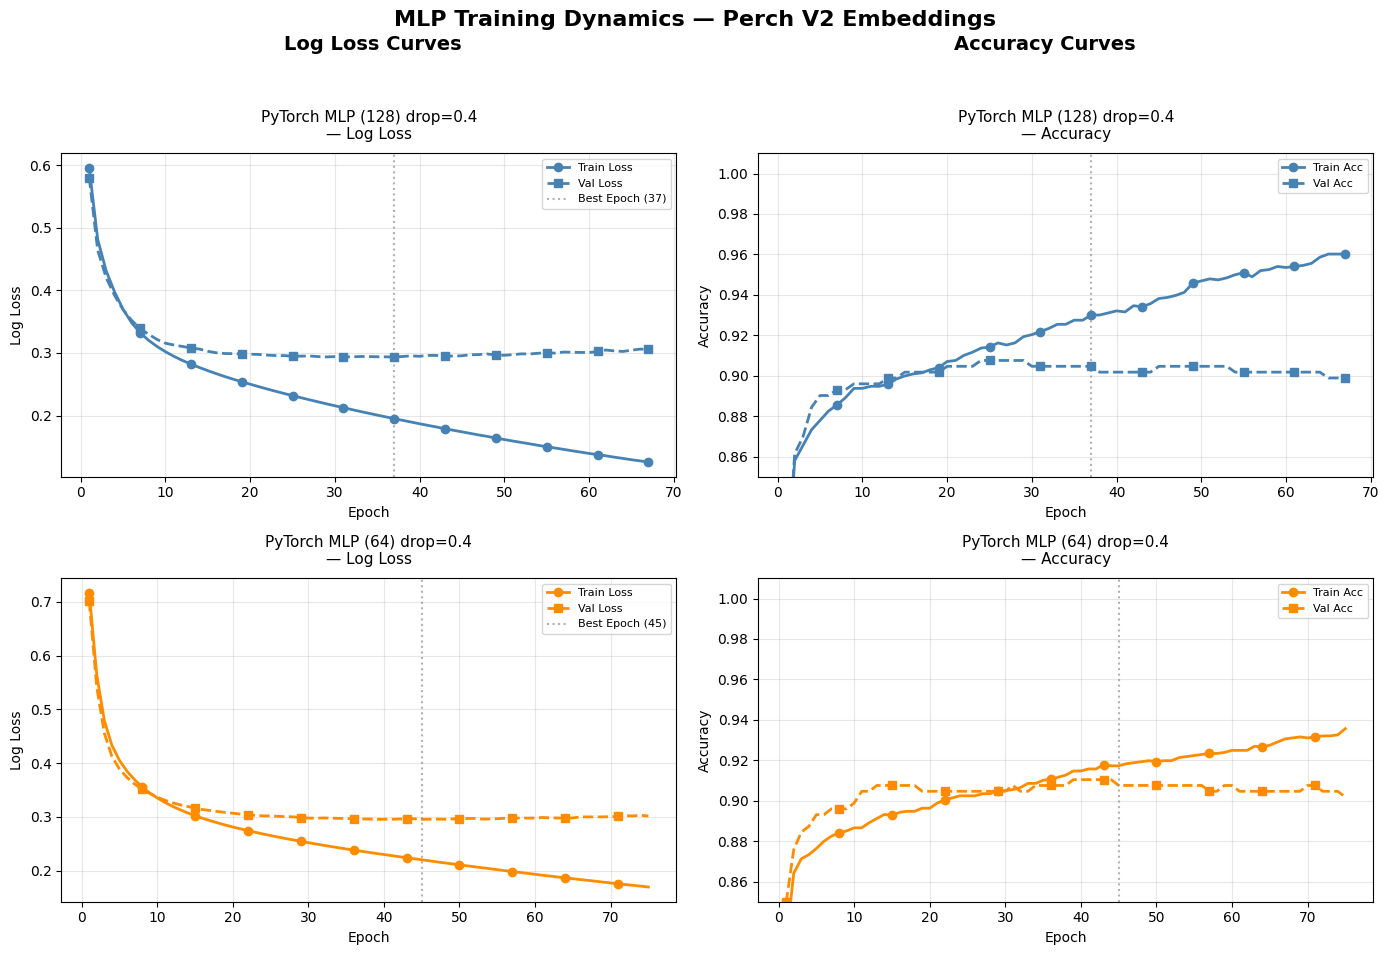

In [19]:
import matplotlib.pyplot as plt
import numpy as np

color_palette = ['steelblue', 'darkorange', 'seagreen']
colors = {name: color_palette[i % len(color_palette)] for i, name in enumerate(mlp_results)}

n_models = len(mlp_results)
fig, axes = plt.subplots(n_models, 2, figsize=(14, 5 * n_models))
if n_models == 1:
    axes = axes[np.newaxis, :]  # ensure 2D indexing works

fig.suptitle('MLP Training Dynamics — Perch V2 Embeddings',
             fontsize=16, fontweight='bold', y=0.98)

for idx, (name, res) in enumerate(mlp_results.items()):
    color = colors[name]
    epochs = np.arange(1, res['n_iter'] + 1)

    ax_loss = axes[idx, 0]
    ax_loss.plot(epochs, res['train_losses'], label='Train Loss',
                 color=color, linewidth=2, marker='o', markevery=max(1, len(epochs)//10))
    ax_loss.plot(epochs, res['val_losses'], label='Val Loss',
                 color=color, linestyle='--', linewidth=2, marker='s', markevery=max(1, len(epochs)//10))
    ax_loss.axvline(res['best_epoch'], color='gray', linestyle=':', alpha=0.6,
                    label=f'Best Epoch ({res["best_epoch"]})')
    ax_loss.set_title(f'{name}\n— Log Loss', fontsize=11, pad=10)
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('Log Loss')
    ax_loss.legend(fontsize=8)
    ax_loss.grid(alpha=0.3)

    ax_acc = axes[idx, 1]
    ax_acc.plot(epochs, res['train_accs'], label='Train Acc',
                color=color, linewidth=2, marker='o', markevery=max(1, len(epochs)//10))
    ax_acc.plot(epochs, res['val_accs'], label='Val Acc',
                color=color, linestyle='--', linewidth=2, marker='s', markevery=max(1, len(epochs)//10))
    ax_acc.axvline(res['best_epoch'], color='gray', linestyle=':', alpha=0.6)
    ax_acc.set_title(f'{name}\n— Accuracy', fontsize=11, pad=10)
    ax_acc.set_xlabel('Epoch')
    ax_acc.set_ylabel('Accuracy')
    ax_acc.legend(fontsize=8)
    ax_acc.grid(alpha=0.3)
    ax_acc.set_ylim(0.85, 1.01)

plt.tight_layout(rect=[0, 0.03, 1, 0.93])
fig.text(0.27, 0.94, 'Log Loss Curves', fontsize=14, fontweight='bold', ha='center')
fig.text(0.75, 0.94, 'Accuracy Curves', fontsize=14, fontweight='bold', ha='center')

plt.savefig(f'{save_dir}/figures/mlp_4chart_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

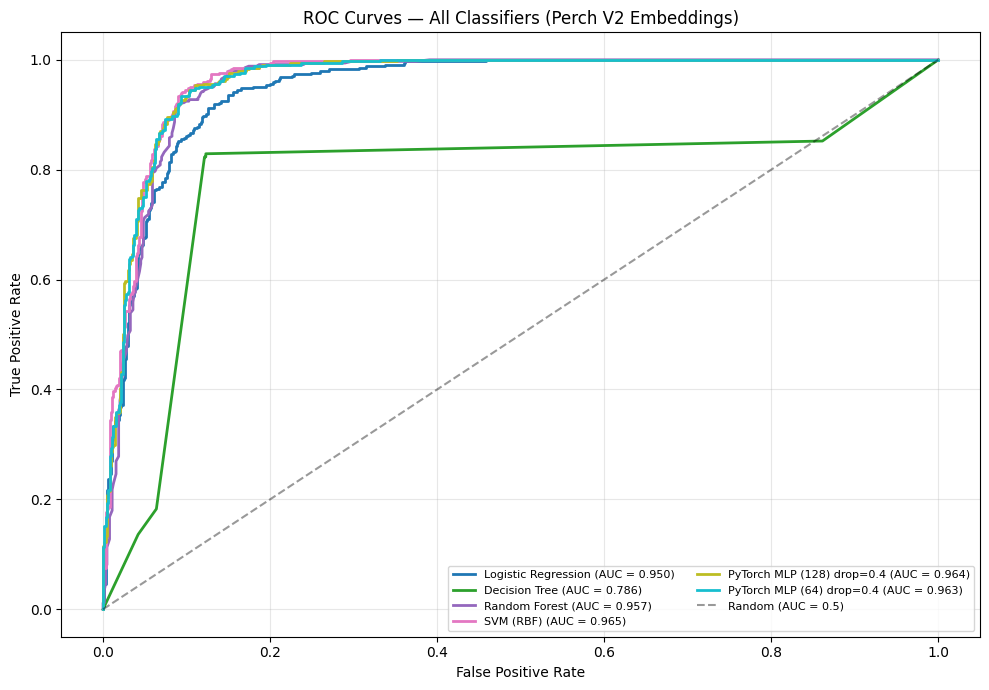

In [ ]:
#@title ROC Curves — ALL Classifiers (including MLPs)
plt.figure(figsize=(10, 7))
colors = plt.cm.tab10(np.linspace(0, 1, len(results)))

for idx, (name, res) in enumerate(results.items()):
    if 'y_proba' in res:  # Only models that stored probabilities
        fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
        auc = roc_auc_score(y_test, res['y_proba'])
        plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', color=colors[idx], linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Classifiers (Perch V2 Embeddings)')
plt.legend(loc='lower right', fontsize=8, ncol=2)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{save_dir}/figures/roc_curves.png', dpi=150)
plt.show()

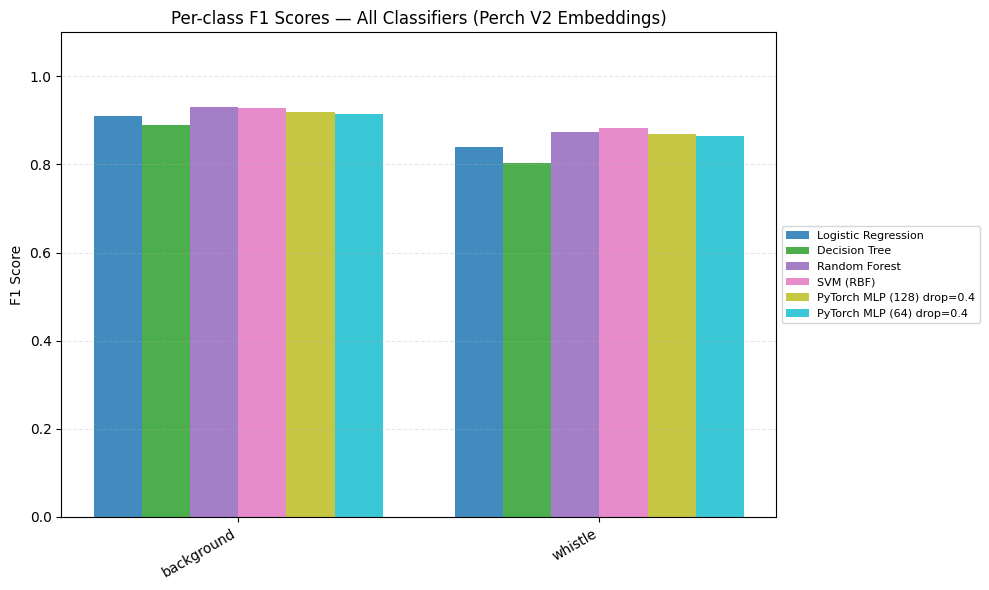

In [21]:
#@title Per-class F1 comparison bar chart — ALL classifiers
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

classifier_names = list(results.keys())
n_classifiers = len(classifier_names)
n_classes = len(class_names)

colors = plt.cm.tab10(np.linspace(0, 1, min(n_classifiers, 10)))
x = np.arange(n_classes)
width = 0.8 / n_classifiers

fig, ax = plt.subplots(figsize=(max(10, n_classes * 1.5), 6))

for i, (name, res) in enumerate(results.items()):
    # PyTorch results use binary int preds; sklearn use encoded class indices
    y_true = y_test_bin.astype(int) if name.startswith('PyTorch') else y_test
    f1_per_class = f1_score(y_true, res['y_pred'],
                            labels=list(range(n_classes)), average=None, zero_division=0)
    offset = (i - n_classifiers/2 + 0.5) * width
    ax.bar(x + offset, f1_per_class, width, label=name,
           color=colors[i % len(colors)], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=30, ha='right')
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1.1)
ax.set_title('Per-class F1 Scores — All Classifiers (Perch V2 Embeddings)')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{save_dir}/figures/f1_comparison_all_classifiers.png', dpi=150, bbox_inches='tight')
plt.show()

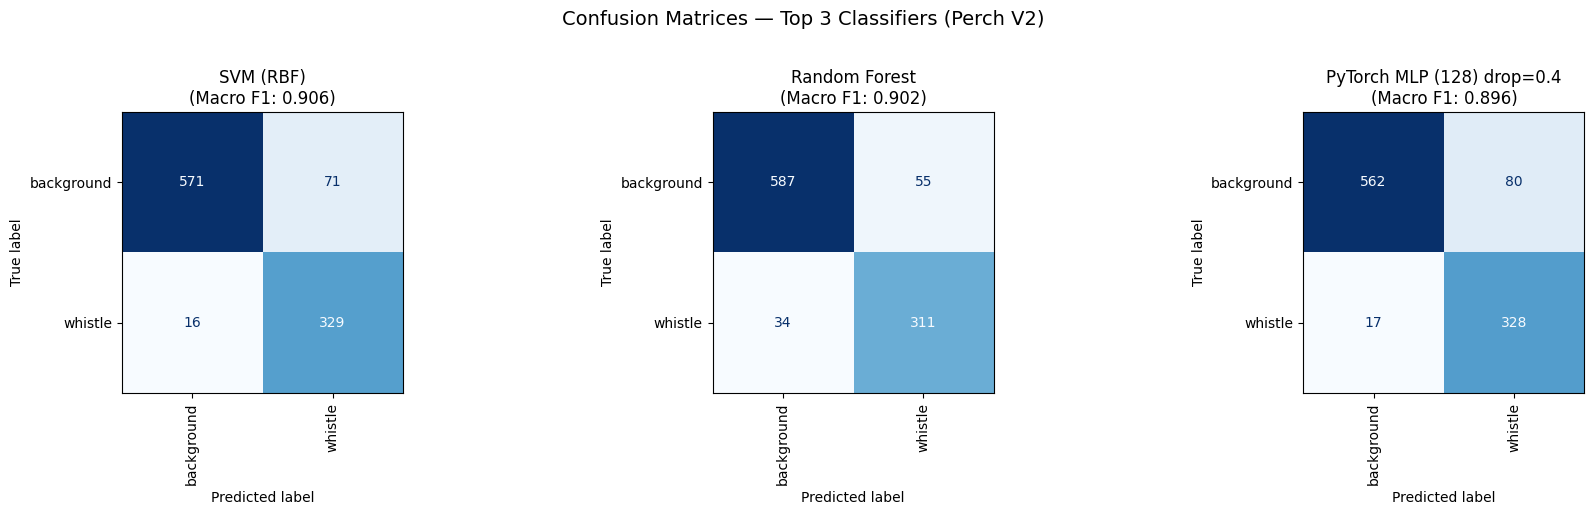

In [ ]:
#@title Confusion matrices — Top N classifiers by Macro F1
from sklearn.metrics import ConfusionMatrixDisplay

TOP_N = 3
top_classifiers = sorted(results.items(), key=lambda x: x[1]['f1_macro'], reverse=True)[:TOP_N]

fig, axes = plt.subplots(1, TOP_N, figsize=(6 * TOP_N, 5))
if TOP_N == 1:
    axes = [axes]

for ax, (name, res) in zip(axes, top_classifiers):
    y_true = y_test_bin.astype(int) if name.startswith('PyTorch') else y_test
    ConfusionMatrixDisplay.from_predictions(
        y_true, res['y_pred'],
        display_labels=class_names,
        ax=ax, colorbar=False, xticks_rotation='vertical', cmap='Blues'
    )
    ax.set_title(f'{name}\n(Macro F1: {res["f1_macro"]:.3f})')

plt.suptitle(f'Confusion Matrices — Top {TOP_N} Classifiers (Perch V2)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{save_dir}/figures/confusion_matrices_top{TOP_N}.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
#@title Save full results to CSV — ALL classifiers
from sklearn.metrics import precision_recall_fscore_support
import pandas as pd

# Prepare rows for CSV
rows = []
for name, res in results.items():
    auc = roc_auc_score(y_test, res['y_proba']) if 'y_proba' in res else None
    p, r, f, s = precision_recall_fscore_support(
        y_test, res['y_pred'], labels=range(len(class_names)), zero_division=0
    )
    row = {
        'classifier': name,
        'macro_f1': res['f1_macro'],
        'time_seconds': res['time_s'],
        'roc_auc': auc
    }
    # Add per-class metrics
    for i, cls in enumerate(class_names):
        row[f'{cls}_precision'] = round(p[i], 3)
        row[f'{cls}_recall'] = round(r[i], 3)
        row[f'{cls}_f1'] = round(f[i], 3)
    # Optional: add support (sample count) once
    if 'support' not in row:
        for i, cls in enumerate(class_names):
            row[f'{cls}_support'] = s[i]
    rows.append(row)

results_df = pd.DataFrame(rows)
# Reorder columns for readability
cols = ['classifier', 'macro_f1', 'time_seconds'] + \
       [c for c in results_df.columns if c not in ['classifier', 'macro_f1', 'time_seconds']]
results_df = results_df[cols]

results_df.to_csv('perch_v2_all_classifiers_results_2.csv', index=False)
print(f'✅ Saved {len(results_df)} classifiers to perch_v2_all_classifiers_results.csv')
display(results_df.round(3))

✅ Saved 6 classifiers to perch_v2_all_classifiers_results.csv


,classifier,macro_f1,time_seconds,roc_auc,background_precision,background_recall,background_f1,whistle_precision,whistle_recall,whistle_f1,background_support,whistle_support
0,Logistic Regression,0.875,0.160,0.950,0.923,0.899,0.911,0.820,0.861,0.840,642,345
1,Decision Tree,0.846,3.694,0.786,0.902,0.877,0.889,0.782,0.823,0.802,642,345
2,Random Forest,0.902,1.190,0.957,0.945,0.914,0.930,0.850,0.901,0.875,642,345
3,SVM (RBF),0.906,7.630,0.965,0.973,0.889,0.929,0.822,0.954,0.883,642,345
4,PyTorch MLP (128) drop=0.4,0.894,2.301,0.964,0.974,0.869,0.919,0.797,0.957,0.870,642,345
5,PyTorch MLP (64) drop=0.4,0.890,2.217,0.963,0.974,0.863,0.915,0.789,0.957,0.865,642,345


: 

Running full PCA...

Total components: 1536

PCA Variance Explained (first 30 components):
Component  Variance Explained (%)  Cumulative (%)
      PC1                 11.8370         11.8370
      PC2                  7.8566         19.6936
      PC3                  5.6989         25.3925
      PC4                  5.2711         30.6635
      PC5                  3.6125         34.2761
      PC6                  3.0013         37.2774
      PC7                  2.6008         39.8782
      PC8                  2.0980         41.9762
      PC9                  1.7190         43.6953
     PC10                  1.4243         45.1196
     PC11                  1.3757         46.4953
     PC12                  1.2517         47.7469
     PC13                  1.2064         48.9533
     PC14                  1.1262         50.0795
     PC15                  1.0030         51.0825
     PC16                  0.9318         52.0144
     PC17                  0.9170         52.9313
     PC18

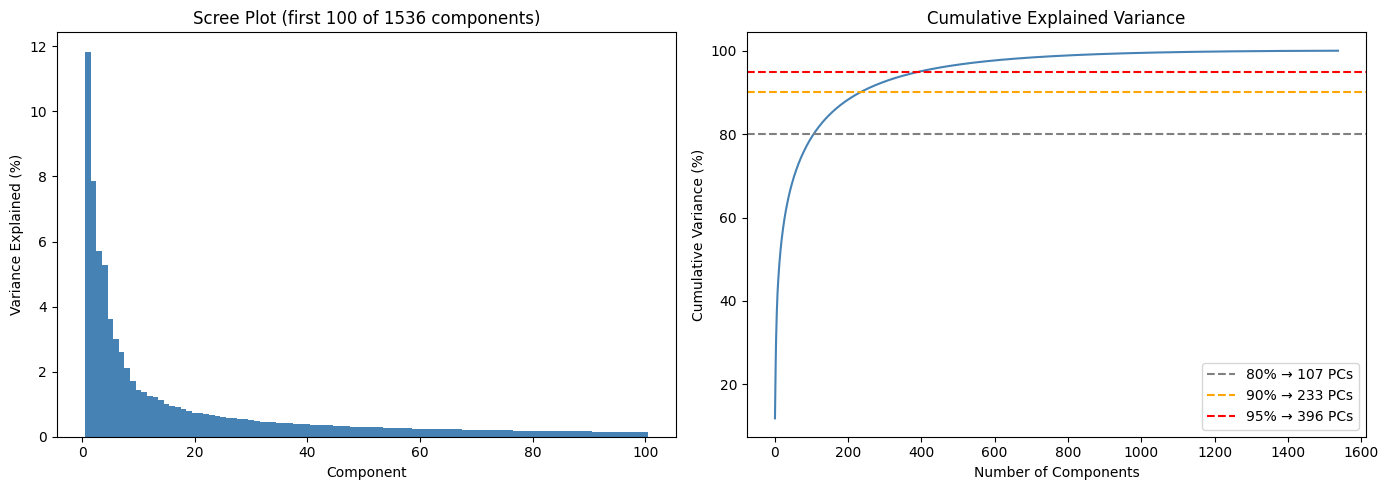

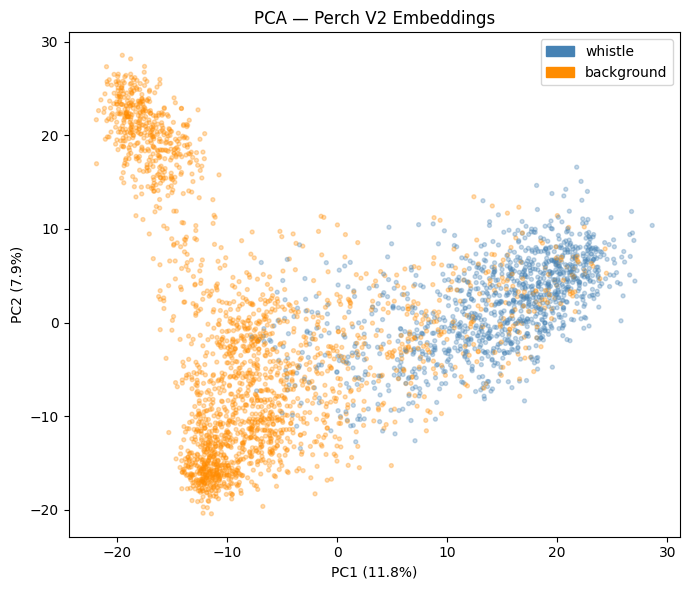


PCA-reduced shape for t-SNE/UMAP input: (3290, 233)

Running t-SNE with multiple distance metrics...
  t-SNE metric: euclidean...
  t-SNE metric: cosine...
  t-SNE metric: manhattan...
  t-SNE metric: correlation...


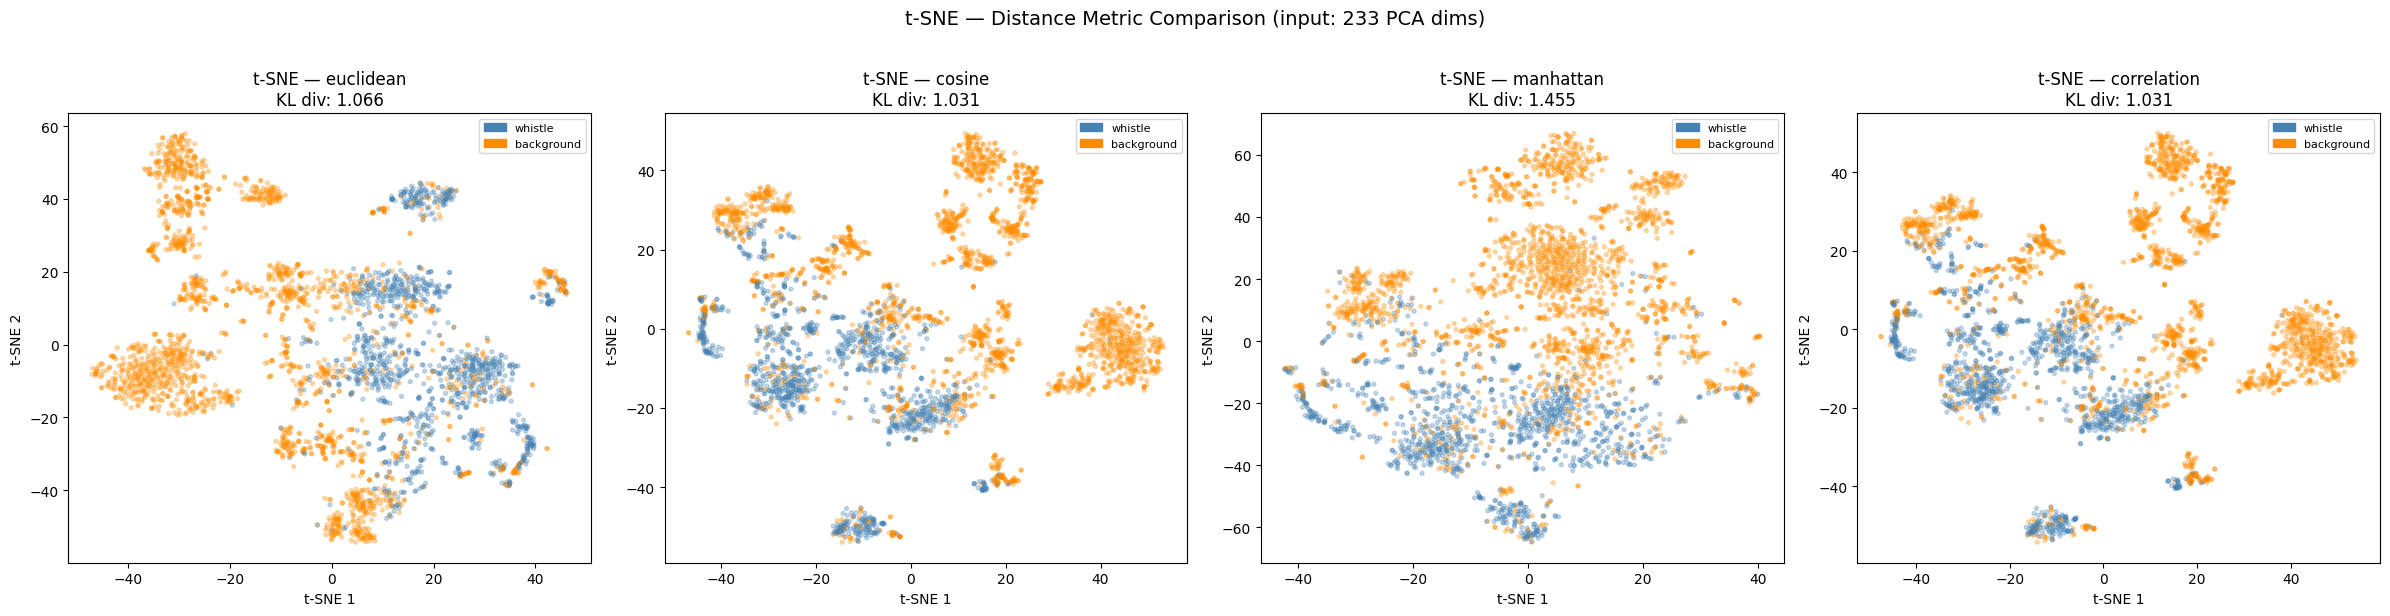


Running UMAP with multiple distance metrics...
  UMAP metric: euclidean...
  UMAP metric: cosine...
  UMAP metric: manhattan...
  UMAP metric: correlation...


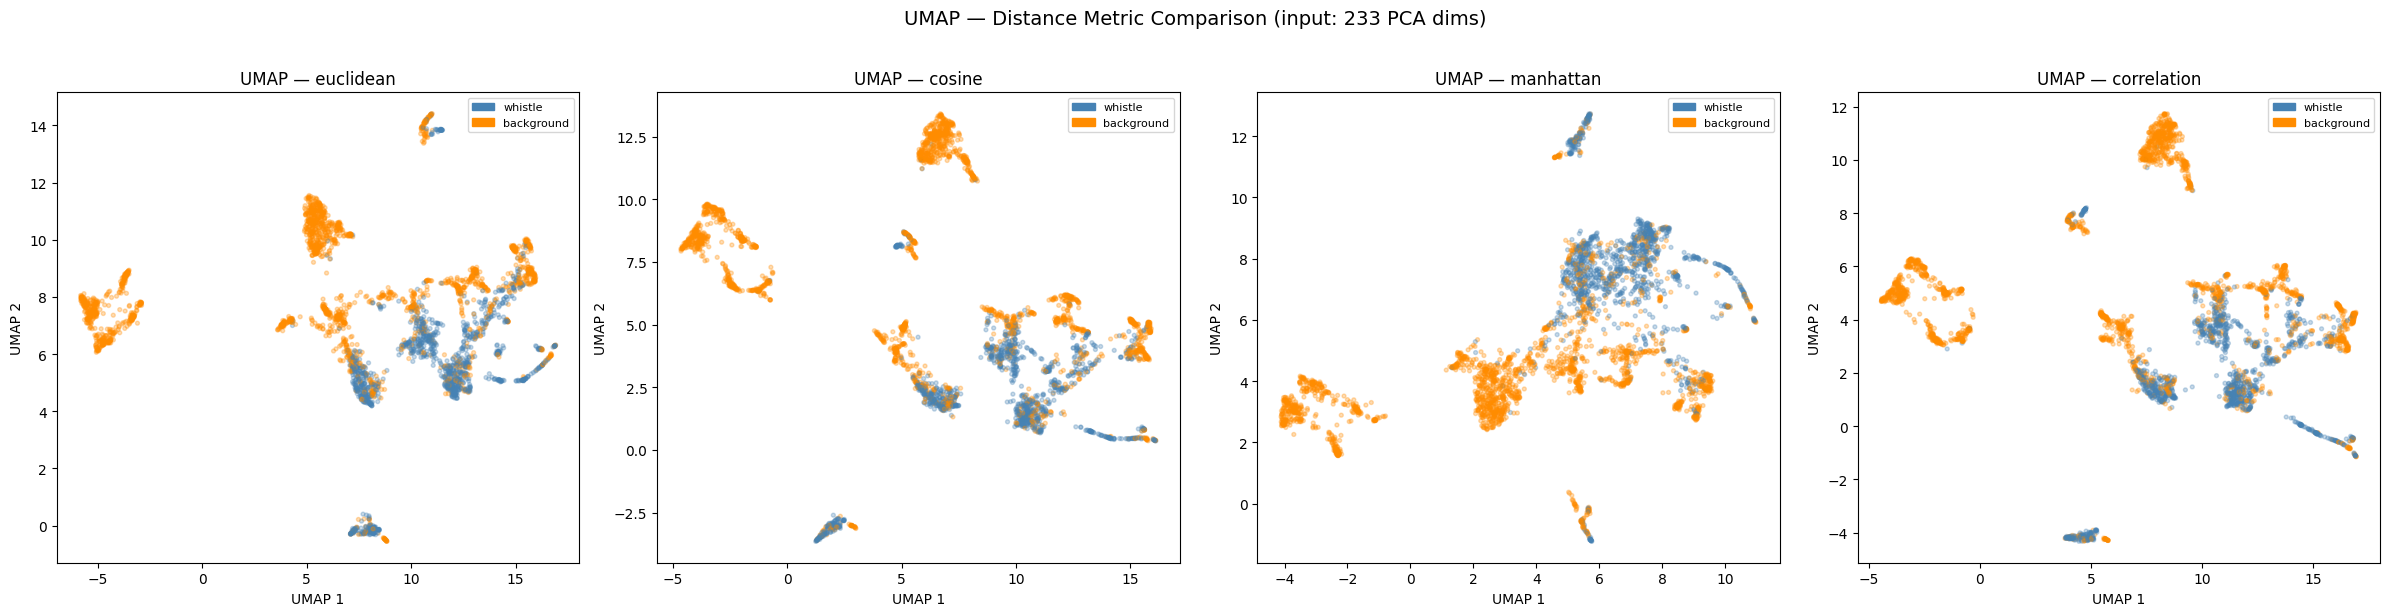


SUMMARY
PCA input dims: 1536 → reduced to 233 (90% variance)

t-SNE KL Divergence by metric (lower = better fit):
  cosine           KL: 1.0308
  correlation      KL: 1.0313
  euclidean        KL: 1.0655
  manhattan        KL: 1.4551

All coordinates saved.


In [35]:
#@title Dimensionality reduction — Full PCA analysis + multi-metric t-SNE & UMAP
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Standardize embeddings
scaler_viz = StandardScaler()
X_scaled = scaler_viz.fit_transform(X_clean)

# Color setup
colors = {'whistle': 'steelblue', 'background': 'darkorange'}
c = np.array([colors[label] for label in y_clean])
alpha = 0.3
s = 8
legend_patches = [
    mpatches.Patch(color='steelblue', label='whistle'),
    mpatches.Patch(color='darkorange', label='background')
]

# ═══════════════════════════════════════════════════════════════════════════════
# 1. FULL PCA — Variance analysis
# ═══════════════════════════════════════════════════════════════════════════════
print('Running full PCA...')
pca_full = PCA(random_state=random_seed)
pca_full.fit(X_scaled)

n_total = len(pca_full.explained_variance_ratio_)
cumvar_full = np.cumsum(pca_full.explained_variance_ratio_) * 100

# Variance table — all components
var_df = pd.DataFrame({
    'Component': [f'PC{i+1}' for i in range(n_total)],
    'Variance Explained (%)': pca_full.explained_variance_ratio_ * 100,
    'Cumulative (%)': cumvar_full
})

# Print first 30 components
print(f'\nTotal components: {n_total}')
print(f'\nPCA Variance Explained (first 30 components):')
print(var_df.head(30).to_string(index=False, float_format='%.4f'))

# Key thresholds
n80 = np.argmax(cumvar_full >= 80) + 1
n90 = np.argmax(cumvar_full >= 90) + 1
n95 = np.argmax(cumvar_full >= 95) + 1
n99 = np.argmax(cumvar_full >= 99) + 1
print(f'\nComponents for 80% variance: {n80}')
print(f'Components for 90% variance: {n90}')
print(f'Components for 95% variance: {n95}')
print(f'Components for 99% variance: {n99}')

# Choose n_components for t-SNE input — 90% variance is a good default
n_pca = n90
print(f'\n→ Using {n_pca} PCA components for t-SNE input (90% variance)')

# Scree plot + cumulative (R-style)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Scree — individual variance per component (zoom to first 100)
n_show = min(100, n_total)
ax1.bar(range(1, n_show + 1), pca_full.explained_variance_ratio_[:n_show] * 100,
        color='steelblue', width=1.0)
ax1.set_xlabel('Component')
ax1.set_ylabel('Variance Explained (%)')
ax1.set_title(f'Scree Plot (first {n_show} of {n_total} components)')

# Cumulative
ax2.plot(range(1, n_total + 1), cumvar_full, color='steelblue')
ax2.axhline(80, color='gray', linestyle='--', label=f'80% → {n80} PCs')
ax2.axhline(90, color='orange', linestyle='--', label=f'90% → {n90} PCs')
ax2.axhline(95, color='red', linestyle='--', label=f'95% → {n95} PCs')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Variance (%)')
ax2.set_title('Cumulative Explained Variance')
ax2.legend()

plt.tight_layout()
plt.savefig(f'{save_dir}/dim_red/pca_full_variance.png', dpi=150)
plt.show()

# PCA 2D scatter
pca2 = PCA(n_components=2, random_state=random_seed)
X_pca2 = pca2.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(X_pca2[:, 0], X_pca2[:, 1], c=c, alpha=alpha, s=s)
ax.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA — Perch V2 Embeddings')
ax.legend(handles=legend_patches)
plt.tight_layout()
plt.savefig(f'{save_dir}/dim_red/pca_2d.png', dpi=150)
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 2. PCA-reduce for t-SNE and UMAP input (consistent input for both)
# ═══════════════════════════════════════════════════════════════════════════════
pca_red = PCA(n_components=n_pca, random_state=random_seed)
X_pca_red = pca_red.fit_transform(X_scaled)
print(f'\nPCA-reduced shape for t-SNE/UMAP input: {X_pca_red.shape}')

# ═══════════════════════════════════════════════════════════════════════════════
# 3. t-SNE — Multiple distance metrics
# ═══════════════════════════════════════════════════════════════════════════════
metrics = ['euclidean', 'cosine', 'manhattan', 'correlation']

print('\nRunning t-SNE with multiple distance metrics...')
fig, axes = plt.subplots(1, 4, figsize=(24, 6))
tsne_results = {}

for ax, metric in zip(axes, metrics):
    print(f'  t-SNE metric: {metric}...')
    tsne = TSNE(
        n_components=2,
        perplexity=40,
        learning_rate='auto',
        init='random' if metric != 'euclidean' else 'pca',
        max_iter=1000,
        metric=metric,
        random_state=random_seed,
        verbose=0
    )
    X_tsne = tsne.fit_transform(X_pca_red)
    tsne_results[metric] = {'coords': X_tsne, 'kl': tsne.kl_divergence_}

    ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=c, alpha=alpha, s=s)
    ax.set_title(f't-SNE — {metric}\nKL div: {tsne.kl_divergence_:.3f}')
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    ax.legend(handles=legend_patches, fontsize=8)

plt.suptitle(f't-SNE — Distance Metric Comparison (input: {n_pca} PCA dims)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{save_dir}/dim_red/tsne_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 4. UMAP — Multiple distance metrics (same PCA input for fair comparison)
# ═══════════════════════════════════════════════════════════════════════════════
print('\nRunning UMAP with multiple distance metrics...')
try:
    import umap
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'umap-learn', '-q'])
    import umap

fig, axes = plt.subplots(1, 4, figsize=(24, 6))
umap_results = {}

for ax, metric in zip(axes, metrics):
    print(f'  UMAP metric: {metric}...')
    reducer = umap.UMAP(
        n_neighbors=30,
        min_dist=0.1,
        n_components=2,
        metric=metric,
        random_state=random_seed,
        verbose=False
    )
    X_umap = reducer.fit_transform(X_pca_red)
    umap_results[metric] = X_umap

    ax.scatter(X_umap[:, 0], X_umap[:, 1], c=c, alpha=alpha, s=s)
    ax.set_title(f'UMAP — {metric}')
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    ax.legend(handles=legend_patches, fontsize=8)

plt.suptitle(f'UMAP — Distance Metric Comparison (input: {n_pca} PCA dims)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{save_dir}/dim_red/umap_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 5. Summary
# ═══════════════════════════════════════════════════════════════════════════════
print('\n' + '=' * 60)
print('SUMMARY')
print('=' * 60)
print(f'PCA input dims: {X_scaled.shape[1]} → reduced to {n_pca} (90% variance)')
print(f'\nt-SNE KL Divergence by metric (lower = better fit):')
for metric, data in sorted(tsne_results.items(), key=lambda x: x[1]['kl']):
    print(f'  {metric:15s}  KL: {data["kl"]:.4f}')

# ── Save all coordinates ────────────────────────────────────────────────────
np.save(f'{save_dir}/dim_red/coords_pca2.npy', X_pca2)
for metric in metrics:
    np.save(f'{save_dir}/dim_red/coords_tsne_{metric}.npy', tsne_results[metric]['coords'])
    np.save(f'{save_dir}/dim_red/coords_umap_{metric}.npy', umap_results[metric])
print('\nAll coordinates saved.')

In [36]:
from sklearn.metrics import silhouette_score
from sklearn.manifold import trustworthiness

print('\n' + '=' * 80)
print('QUANTITATIVE QUALITY METRICS')
print('=' * 80)
print(f'{"Method":<20} {"Metric":<15} {"Trustworthiness":>16} {"Silhouette":>12}')
print('-' * 80)

y_numeric = np.array([0 if label == 'background' else 1 for label in y_clean])

# t-SNE quality
for metric, data in tsne_results.items():
    trust = trustworthiness(X_pca_red, data['coords'], n_neighbors=15)
    sil = silhouette_score(data['coords'], y_numeric)
    print(f'{"t-SNE":<20} {metric:<15} {trust:>16.4f} {sil:>12.4f}')

print()

# UMAP quality
for metric, coords in umap_results.items():
    trust = trustworthiness(X_pca_red, coords, n_neighbors=15)
    sil = silhouette_score(coords, y_numeric)
    print(f'{"UMAP":<20} {metric:<15} {trust:>16.4f} {sil:>12.4f}')

print()

# PCA baseline
trust_pca = trustworthiness(X_pca_red, X_pca2, n_neighbors=15)
sil_pca = silhouette_score(X_pca2, y_numeric)
print(f'{"PCA (2D)":<20} {"euclidean":<15} {trust_pca:>16.4f} {sil_pca:>12.4f}')


QUANTITATIVE QUALITY METRICS
Method               Metric           Trustworthiness   Silhouette
--------------------------------------------------------------------------------
t-SNE                euclidean                 0.9764       0.1689
t-SNE                cosine                    0.9767       0.1860
t-SNE                manhattan                 0.9615       0.2849
t-SNE                correlation               0.9768       0.1865

UMAP                 euclidean                 0.9661       0.1308
UMAP                 cosine                    0.9681       0.1447
UMAP                 manhattan                 0.9471       0.2237
UMAP                 correlation               0.9677       0.1224

PCA (2D)             euclidean                 0.8036       0.3400
